In [11]:
"""
ml/train_comment_spam.py
Run this once to train and save the spam classifier.
"""
import pandas as pd
import re
import joblib
import os
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report

youtube_files = [
    r"D:\raamp-fyp-final\raamp-backend\data\kaggle\Youtube01-Psy.csv",
    r"D:\raamp-fyp-final\raamp-backend\data\kaggle\Youtube02-KatyPerry.csv",
    r"D:\raamp-fyp-final\raamp-backend\data\kaggle\Youtube03-LMFAO.csv",
    r"D:\raamp-fyp-final\raamp-backend\data\kaggle\Youtube04-Eminem.csv",
    r"D:\raamp-fyp-final\raamp-backend\data\kaggle\Youtube05-Shakira.csv",
]

yt_frames = []
for f in youtube_files:
    df = pd.read_csv(f)
    yt_frames.append(df[["CONTENT", "CLASS"]])

yt_data = pd.concat(yt_frames, ignore_index=True)
yt_data.columns = ["text", "label"]
print(f"YouTube rows: {len(yt_data)}")

sms_data = pd.read_csv(
    r"D:\raamp-fyp-final\raamp-backend\data\kaggle\SMSSpamCollection.txt",
    sep="\t",
    header=None,
    names=["label_text", "text"],
    encoding="latin-1"
)
sms_data["label"] = sms_data["label_text"].map({"spam": 1, "ham": 0})
sms_data = sms_data[["text", "label"]]
print(f"SMS rows: {len(sms_data)}")

data = pd.concat([yt_data, sms_data], ignore_index=True)
data = data.dropna()
print(f"Total rows: {len(data)}")
print(f"Spam: {data['label'].sum()} | Ham: {(data['label'] == 0).sum()}")

def clean_comment(text):
    text = str(text).lower()
    text = re.sub(r'http\S+', '', text)
    text = re.sub(r'[^a-z0-9\s!?]', '', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

data["text"] = data["text"].apply(clean_comment)

vectorizer = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1, 2),
    stop_words='english'
)
X = vectorizer.fit_transform(data["text"])
y = data["label"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

model = LogisticRegression(max_iter=1000, class_weight='balanced')
model.fit(X_train, y_train)

print("\n── Evaluation ──")
print(classification_report(y_test, model.predict(X_test)))

os.makedirs("ml/models", exist_ok=True)
joblib.dump(model, "ml/models/spam_classifier.pkl")
joblib.dump(vectorizer, "ml/models/spam_vectorizer.pkl")
print("✅ Saved: ml/models/spam_classifier.pkl")
print("✅ Saved: ml/models/spam_vectorizer.pkl")

YouTube rows: 1956
SMS rows: 5572
Total rows: 7528
Spam: 1752 | Ham: 5776

── Evaluation ──
              precision    recall  f1-score   support

           0       0.95      0.97      0.96      1156
           1       0.90      0.84      0.87       350

    accuracy                           0.94      1506
   macro avg       0.93      0.91      0.92      1506
weighted avg       0.94      0.94      0.94      1506

✅ Saved: ml/models/spam_classifier.pkl
✅ Saved: ml/models/spam_vectorizer.pkl


In [2]:
import joblib
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
import pandas as pd
import re

# Reload model and vectorizer
model = joblib.load(r"D:\raamp-fyp-final\raamp-backend\ml\models\spam_classifier.pkl")
vectorizer = joblib.load(r"D:\raamp-fyp-final\raamp-backend\ml\models\spam_vectorizer.pkl")

# Reload and reprocess data to get y_test
youtube_files = [
    r"D:\raamp-fyp-final\raamp-backend\data\kaggle\Youtube01-Psy.csv",
    r"D:\raamp-fyp-final\raamp-backend\data\kaggle\Youtube02-KatyPerry.csv",
    r"D:\raamp-fyp-final\raamp-backend\data\kaggle\Youtube03-LMFAO.csv",
    r"D:\raamp-fyp-final\raamp-backend\data\kaggle\Youtube04-Eminem.csv",
    r"D:\raamp-fyp-final\raamp-backend\data\kaggle\Youtube05-Shakira.csv",
]
yt_frames = [pd.read_csv(f)[["CONTENT", "CLASS"]].rename(columns={"CONTENT": "text", "CLASS": "label"}) for f in youtube_files]
yt_data = pd.concat(yt_frames, ignore_index=True)

sms_data = pd.read_csv(r"D:\raamp-fyp-final\raamp-backend\data\kaggle\SMSSpamCollection.txt",
    sep="\t", header=None, names=["label_text", "text"], encoding="latin-1")
sms_data["label"] = sms_data["label_text"].map({"spam": 1, "ham": 0})
sms_data = sms_data[["text", "label"]]

data = pd.concat([yt_data, sms_data], ignore_index=True).dropna()

def clean_comment(text):
    text = str(text).lower()
    text = re.sub(r'http\S+', '', text)
    text = re.sub(r'[^a-z0-9\s!?]', '', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

data["text"] = data["text"].apply(clean_comment)
X = vectorizer.transform(data["text"])
y = data["label"]

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Ready")

Ready


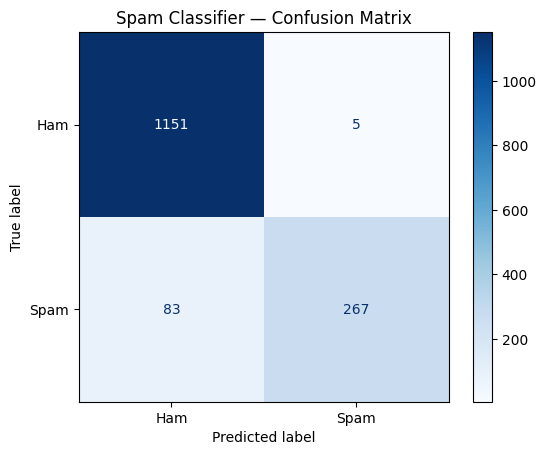

In [3]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, model.predict(X_test))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Ham", "Spam"])
disp.plot(cmap="Blues")
plt.title("Spam Classifier — Confusion Matrix")
plt.savefig("confusion_matrix.png", dpi=150)
plt.show()

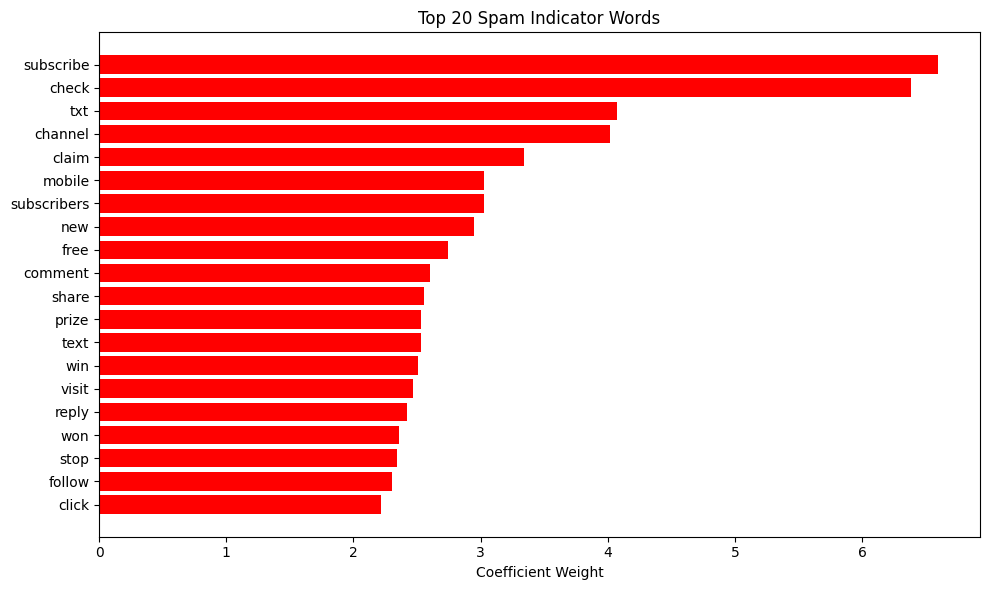

In [4]:
import numpy as np

feature_names = vectorizer.get_feature_names_out()
coefs = model.coef_[0]
top_spam_idx = np.argsort(coefs)[-20:]
top_ham_idx = np.argsort(coefs)[:20]

plt.figure(figsize=(10, 6))
plt.barh(feature_names[top_spam_idx], coefs[top_spam_idx], color="red", label="Spam")
plt.title("Top 20 Spam Indicator Words")
plt.xlabel("Coefficient Weight")
plt.tight_layout()
plt.savefig("top_spam_features.png", dpi=150)
plt.show()

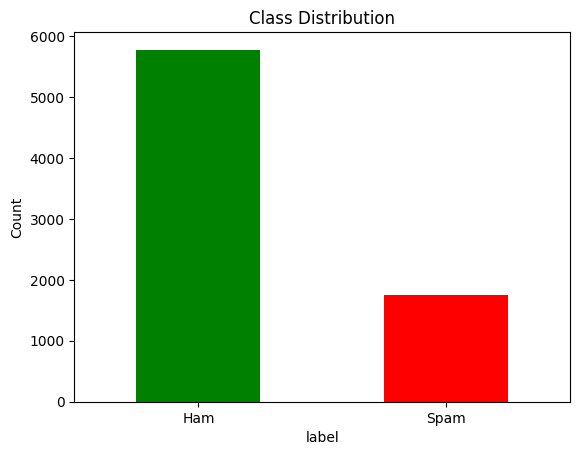

In [5]:
data["label"].value_counts().plot(kind="bar", color=["green", "red"])
plt.xticks([0, 1], ["Ham", "Spam"], rotation=0)
plt.title("Class Distribution")
plt.ylabel("Count")
plt.savefig("class_distribution.png", dpi=150)
plt.show()